In [1]:
import sys, time
sys.path.insert(0, '../src')

import priceModels as pm
import amOptPricer as aop
import reporting as rpt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Table of Contents

1. [LLH Model Definition](#llh-model) — Lin, Lin & He (2024)
2. [Simulate Price Paths](#simulate) — Lin, Lin & He Table 1 and Table 2 parameters
3. [European Prices: LLH Formula vs Monte Carlo](#european-prices)
   - 3.1 One-month horizon
   - 3.2 One-year horizon
4. [Timing: Numerical LLH vs Monte Carlo](#timing) — both horizons
5. [Edge-Case Validation](#edge-cases)
   - 5.1 Black-Scholes limit
   - 5.2 Stein & Stein (1991) limit — Table 1 parameters
   - 5.3 Reproducing Schöbel & Zhu (1999) Table 2

<a id="llh-model"></a>
## 1. Improved Stein-Stein (LLH) Model

\begin{align}
    \frac{dS_t}{S_t} &= rdt + \sigma_tdW^1_t\\
    d\sigma_t &= \kappa(\theta_t-\sigma_t)dt + \nu dW^2_t\\
    d\theta_t &= \lambda dt + \eta dB_t\\
    dB_t &= B_t dW_t,\,B_0=1\\
    \text{ }\notag\\
    \text{cov}&(W^1_t,W^2_t)=\rho t \notag
\end{align}

- $W^1_t,\,W^2_t$ are correlated Brownian motions, $W_t$ independent Brownian motion
- $\Theta = (\kappa,\,\nu,\,\lambda,\,\eta,\, \rho)$ are the model parameters

### Note on the LLH paper

Our implementation corrects an error present in Lin, Lin & He (2024,
*Analytically Pricing European Options under a New Two-Factor Stochastic
Volatility Model*). Specifically, the ODE system for the characteristic
function coefficients $(A, B, C, D)$ is **autonomous** — it depends only on
the current state, not on the remaining time $\tau$. The paper's presentation
suggests a $\tau$-dependent right-hand side for $dD$, which is incorrect.

The close agreement between our corrected numerical LLH prices and independent
Monte Carlo estimates throughout this notebook serves as evidence that the
correction is valid.

<a id="simulate"></a>
## 2. Simulate Price Paths

We simulate price paths from the LLH model using Algorithm 2.5 from the report.
Parameters are taken from the Lin-Lin-He paper, Tables 1 and 2 respectively.
Ten thousand paths are sampled over a 1-year horizon with 252 trading days.

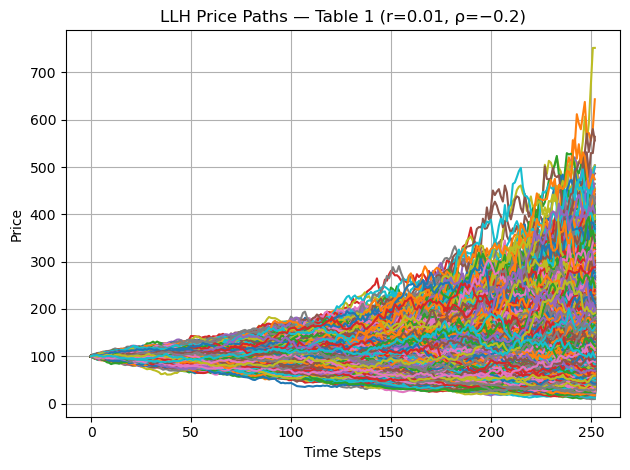

In [2]:
# Table 1 parameters
model_t1 = pm.ImprovedSteinStein(
    r=0.01, rho=-0.2, kappa=5, nu=0.2,
    sigma0=0.15, theta0=0.18, lam=0.9, eta=0.01, seed=123
)
res_t1 = model_t1.simulate_prices(S0=100.0, T=1.0, n_steps_mc=252, n_paths=10000)
pm.plot(res_t1['S'].T, title="LLH Price Paths — Table 1 (r=0.01, ρ=−0.2)")

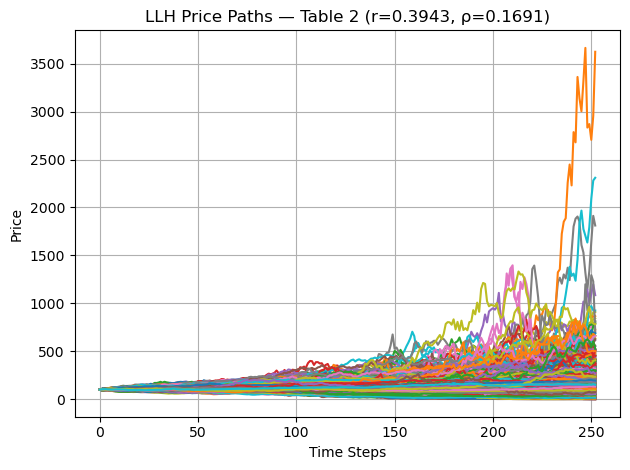

In [3]:
# Table 2 parameters
model_t2 = pm.ImprovedSteinStein(
    r=0.3943, rho=0.1691, kappa=4.9394, nu=0.4,
    sigma0=0.2924, theta0=0.1319, lam=0.3115, eta=0.4112, seed=123
)
res_t2 = model_t2.simulate_prices(S0=100.0, T=1.0, n_steps_mc=252, n_paths=10000)
pm.plot(res_t2['S'].T, title="LLH Price Paths — Table 2 (r=0.3943, ρ=0.1691)")

<a id="european-prices"></a>
## 3. European Prices: LLH Formula vs Monte Carlo

We compute European option prices using the analytical formula from
Lin, Lin & He (2024, *Analytically Pricing European Options under a New
Two-Factor Stochastic Volatility Model*) and compare with Monte Carlo
estimates from 1,000,000 simulated paths. Results are shown for both
parameter sets across two time horizons: one month and one year.

In [4]:
S_vals = [90.0, 95.0, 100.0, 105.0, 110.0]
K_vals = [0.9 * s for s in S_vals]
n_paths = 100_000
phi_max = 300.0
n_phi = 500
n_steps_ode = 100

### 3.1 One-month horizon ($\tau = 1/12$ yr, 22 trading days)

We price European calls and puts at a short maturity where the ODE approximation
is expected to be most accurate, and compare with Monte Carlo estimates.

#### Lin, Lin & He (2024) — Table 1 parameters

In [5]:
call_df, put_df = rpt.llh_vs_mc(model_t1, S_vals, K_vals, tau=0.083, n_steps_mc=22,
                                  n_paths=n_paths, phi_max=phi_max, n_phi=n_phi, n_steps_ode=n_steps_ode)
print("European Call Prices")
display(call_df)
print("\nEuropean Put Prices")
display(put_df)

European Call Prices


,K,LLH,MC,Bias (%),MC 95% CI
S₀,,,,,
90.0,81.0,9.100859,9.094419,-0.07,"[9.0688, 9.1200]"
95.0,85.5,9.606462,9.599665,-0.07,"[9.5726, 9.6267]"
100.0,90.0,10.112065,10.104910,-0.07,"[10.0765, 10.1334]"
105.0,94.5,10.617668,10.610156,-0.07,"[10.5803, 10.6400]"
110.0,99.0,11.123272,11.115401,-0.07,"[11.0841, 11.1467]"



European Put Prices


,K,LLH,MC,Bias (%),MC 95% CI
S₀,,,,,
90.0,81.0,0.033656,0.031908,-5.48,"[0.0299, 0.0339]"
95.0,85.5,0.035526,0.033680,-5.48,"[0.0316, 0.0358]"
100.0,90.0,0.037396,0.035453,-5.48,"[0.0332, 0.0377]"
105.0,94.5,0.039266,0.037226,-5.48,"[0.0349, 0.0395]"
110.0,99.0,0.041136,0.038998,-5.48,"[0.0366, 0.0414]"


#### Lin, Lin & He (2024) — Table 2 parameters

In [6]:
call_df, put_df = rpt.llh_vs_mc(model_t2, S_vals, K_vals, tau=0.083, n_steps_mc=22,
                                  n_paths=250_000, phi_max=phi_max, n_phi=n_phi, n_steps_ode=n_steps_ode)
print("European Call Prices")
display(call_df)
print("\nEuropean Put Prices")
display(put_df)

European Call Prices


,K,LLH,MC,Bias (%),MC 95% CI
S₀,,,,,
90.0,81.0,11.713360,11.722388,0.08,"[11.6950, 11.7497]"
95.0,85.5,12.364102,12.373632,0.08,"[12.3448, 12.4025]"
100.0,90.0,13.014844,13.024876,0.08,"[12.9945, 13.0553]"
105.0,94.5,13.665586,13.676120,0.08,"[13.6442, 13.7080]"
110.0,99.0,14.316329,14.327363,0.08,"[14.2939, 14.3608]"



European Put Prices


,K,LLH,MC,Bias (%),MC 95% CI
S₀,,,,,
90.0,81.0,0.105389,0.109250,3.53,"[0.1064, 0.1121]"
95.0,85.5,0.111244,0.115320,3.53,"[0.1123, 0.1183]"
100.0,90.0,0.117099,0.121389,3.53,"[0.1182, 0.1246]"
105.0,94.5,0.122954,0.127459,3.53,"[0.1241, 0.1308]"
110.0,99.0,0.128809,0.133528,3.53,"[0.1301, 0.1370]"


### 3.2 One-year horizon ($\tau = 1.0$ yr, 52 weekly steps)

At a longer maturity, the accumulated ODE approximation error becomes visible.
We repeat the same comparison to quantify the bias growth.

#### Lin, Lin & He (2024) — Table 1 parameters

In [7]:
call_df, put_df = rpt.llh_vs_mc(model_t1, S_vals, K_vals, tau=1.0, n_steps_mc=52,
                                  n_paths=250_000, phi_max=phi_max, n_phi=n_phi, n_steps_ode=n_steps_ode)
print("European Call Prices")
display(call_df)
print("\nEuropean Put Prices")
display(put_df)

European Call Prices


,K,LLH,MC,Bias (%),MC 95% CI
S₀,,,,,
90.0,81.0,23.212263,23.099189,-0.49,"[22.9418, 23.2566]"
95.0,85.5,24.501833,24.382477,-0.49,"[24.2163, 24.5486]"
100.0,90.0,25.791403,25.665765,-0.49,"[25.4909, 25.8406]"
105.0,94.5,27.080973,26.949054,-0.49,"[26.7654, 27.1327]"
110.0,99.0,28.370543,28.232342,-0.49,"[28.0400, 28.4247]"



European Put Prices


,K,LLH,MC,Bias (%),MC 95% CI
S₀,,,,,
90.0,81.0,13.406299,13.239724,-1.26,"[13.1721, 13.3073]"
95.0,85.5,14.151093,13.975264,-1.26,"[13.9039, 14.0466]"
100.0,90.0,14.895888,14.710804,-1.26,"[14.6357, 14.7859]"
105.0,94.5,15.640682,15.446345,-1.26,"[15.3675, 15.5252]"
110.0,99.0,16.385477,16.181885,-1.26,"[16.0993, 16.2645]"


#### Lin, Lin & He (2024) — Table 2 parameters

In [9]:
call_df, put_df = rpt.llh_vs_mc(model_t2, S_vals, K_vals, tau=1.0, n_steps_mc=52,
                                  n_paths=500_000, phi_max=phi_max, n_phi=n_phi, n_steps_ode=n_steps_ode)
print("European Call Prices")
display(call_df)
print("\nEuropean Put Prices")
display(put_df)

European Call Prices


,K,LLH,MC,Bias (%),MC 95% CI
S₀,,,,,
90.0,81.0,36.573641,36.574617,0.0,"[36.4450, 36.7042]"
95.0,85.5,38.605510,38.606540,0.0,"[38.4697, 38.7433]"
100.0,90.0,40.637378,40.638463,0.0,"[40.4945, 40.7825]"
105.0,94.5,42.669247,42.670387,0.0,"[42.5192, 42.8216]"
110.0,99.0,44.701116,44.702310,0.0,"[44.5439, 44.8607]"



European Put Prices


,K,LLH,MC,Bias (%),MC 95% CI
S₀,,,,,
90.0,81.0,1.179935,1.372957,14.06,"[1.2851, 1.4608]"
95.0,85.5,1.245487,1.449232,14.06,"[1.3565, 1.5420]"
100.0,90.0,1.311039,1.525507,14.06,"[1.4279, 1.6231]"
105.0,94.5,1.376591,1.601783,14.06,"[1.4993, 1.7043]"
110.0,99.0,1.442143,1.678058,14.06,"[1.5707, 1.7854]"


#### Remarks
- By put-call parity: $P-C=Ke^{-r\tau}-S$, which implies $C_E^{\text{LLH}}-C^{\text{MC}}_E = P_E^{\text{LLH}}-P^{\text{MC}}_E$, so the **absolute** bias is the same for calls and puts.
- The **relative** bias (%) appears larger for puts because puts with $K=0.9S$ have smaller absolute prices — a small absolute error becomes a large percentage.

In [10]:
K_vals = [0.975 * s for s in S_vals]
call_df, put_df = rpt.llh_vs_mc(model_t2, S_vals, K_vals, tau=1.0, n_steps_mc=52,
                                  n_paths=250_000, phi_max=phi_max, n_phi=n_phi, n_steps_ode=n_steps_ode)
print("European Call Prices")
display(call_df)
print("\nEuropean Put Prices")
display(put_df)

European Call Prices


,K,LLH,MC,Bias (%),MC 95% CI
S₀,,,,,
90.0,87.750,32.553768,32.480109,-0.23,"[32.3514, 32.6088]"
95.0,92.625,34.362311,34.284560,-0.23,"[34.1487, 34.4204]"
100.0,97.500,36.170854,36.089010,-0.23,"[35.9460, 36.2320]"
105.0,102.375,37.979396,37.893461,-0.23,"[37.7434, 38.0436]"
110.0,107.250,39.787939,39.697911,-0.23,"[39.5407, 39.8552]"



European Put Prices


,K,LLH,MC,Bias (%),MC 95% CI
S₀,,,,,
90.0,87.750,1.710587,1.828973,6.47,"[1.7406, 1.9174]"
95.0,92.625,1.805620,1.930583,6.47,"[1.8373, 2.0239]"
100.0,97.500,1.900652,2.032192,6.47,"[1.9340, 2.1304]"
105.0,102.375,1.995685,2.133802,6.47,"[2.0306, 2.2370]"
110.0,107.250,2.090718,2.235412,6.47,"[2.1273, 2.3435]"


In [11]:
K_vals = [1.1 * s for s in S_vals]
call_df, put_df = rpt.llh_vs_mc(model_t2, S_vals, K_vals, tau=1.0, n_steps_mc=52,
                                  n_paths=250_000, phi_max=phi_max, n_phi=n_phi, n_steps_ode=n_steps_ode)
print("European Call Prices")
display(call_df)
print("\nEuropean Put Prices")
display(put_df)

European Call Prices


,K,LLH,MC,Bias (%),MC 95% CI
S₀,,,,,
90.0,99.0,26.260946,26.222708,-0.15,"[25.8518, 26.5936]"
95.0,104.5,27.719887,27.679525,-0.15,"[27.2881, 28.0710]"
100.0,110.0,29.178829,29.136342,-0.15,"[28.7243, 29.5484]"
105.0,115.5,30.637770,30.593159,-0.15,"[30.1605, 31.0258]"
110.0,121.0,32.096712,32.049976,-0.15,"[31.5967, 32.5033]"



European Put Prices


,K,LLH,MC,Bias (%),MC 95% CI
S₀,,,,,
90.0,99.0,3.001972,2.964162,-1.28,"[2.7520, 3.1763]"
95.0,104.5,3.168749,3.128837,-1.28,"[2.9049, 3.3527]"
100.0,110.0,3.335525,3.293513,-1.28,"[3.0578, 3.5292]"
105.0,115.5,3.502301,3.458189,-1.28,"[3.2107, 3.7057]"
110.0,121.0,3.669077,3.622864,-1.28,"[3.3636, 3.8821]"


<a id="timing"></a>
## 4. Timing: Numerical LLH vs Monte Carlo

We compare the wall-clock cost of computing a single European call price via
the analytical LLH formula (ODE + quadrature) versus Monte Carlo simulation,
for both the one-month and one-year horizons.

In [12]:
S0, K = 100.0, 90.0

for label, tau, n_steps_mc in [("1 month (τ=0.083)", 0.083, 22),
                                ("1 year  (τ=1.0)",  1.0,   52)]:
    # ── Numerical LLH ──────────────────────────────────────────────────────
    t0 = time.perf_counter()
    p_llh = model_t2.price_call_llh(S=S0, K=K, tau=tau,
                                     vol=model_t2.sigma0, theta=model_t2.theta0,
                                     phi_max=300.0, n_phi=513, n_steps_ode=128).item()
    t_llh = time.perf_counter() - t0

    # ── Monte Carlo ─────────────────────────────────────────────────────────
    t0 = time.perf_counter()
    res_mc = model_t2.simulate_prices(S0=S0, T=tau, n_steps_mc=n_steps_mc, n_paths=250_000)
    p_mc = aop.price_call_mc(res_mc['S'], K=K, T=tau, r=model_t2.r)['price']
    t_mc = time.perf_counter() - t0

    print(f"\n── {label} ──")
    print(f"{'Method':<20} {'Price':>12} {'Time (s)':>10}")
    print(f"{'-'*44}")
    print(f"{'Numerical LLH':<20} {p_llh:>12.6f} {t_llh:>10.4f}")
    print(f"{'Monte Carlo (250K)':<20} {p_mc:>12.6f} {t_mc:>10.4f}")
    print(f"{'Speedup':<20} {'':>12} {t_mc/t_llh:>10.1f}x")


── 1 month (τ=0.083) ──
Method                      Price   Time (s)
--------------------------------------------
Numerical LLH           13.014844     0.0585
Monte Carlo (250K)      13.024876     0.4486
Speedup                                  7.7x

── 1 year  (τ=1.0) ──
Method                      Price   Time (s)
--------------------------------------------
Numerical LLH           40.637378     0.0560
Monte Carlo (250K)      40.899831     1.2693
Speedup                                 22.7x


<a id="edge-cases"></a>
## 5. Edge-Case Validation

We verify the LLH implementation against known limiting cases. When the
stochastic volatility parameters are switched off, the model should recover
Black-Scholes and Stein-Stein prices exactly.

### 5.1 Black-Scholes (1973) limit: $\kappa=\nu=\lambda=\eta=\rho=0$

Setting all stochastic volatility parameters to zero reduces the LLH model to
geometric Brownian motion. The LLH formula should match the closed-form
Black-Scholes price to machine precision.

#### Simulate Price Paths

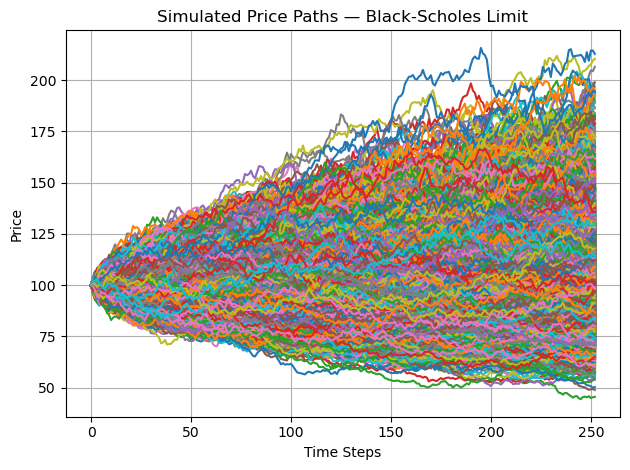

In [13]:
model_bs = pm.ImprovedSteinStein(
    r=0.05, rho=0.0, kappa=0.0, nu=0.0,
    sigma0=0.2, theta0=0.0, lam=0.0, eta=0.0, seed=123
)
res_bs = model_bs.simulate_prices(S0=100.0, T=1.0, n_steps_mc=252, n_paths=10000)
pm.plot(res_bs['S'].T, title="Simulated Price Paths — Black-Scholes Limit")

#### Test of Lognormality

We draw price paths from the LLH (BS-limit) model and consider the price slice
at the end of the horizon $T$. It should follow the BS log-normal distribution.

In [14]:
pm.test_lognormality(res_bs['S'][:, -1])

KS statistic: 0.0051, p-value: 0.9547
Fail to reject null: data may be lognormal.


#### Compare European Option Prices

In [15]:
S, K, tau, vol, theta = 100, 90, 1.0, 0.2, 0.0
price_llh = model_bs.price_call_llh(S, K, tau, vol, theta).item()
price_bs  = aop.price_call_bs(S=100, K=90, tau=1.0, r=0.05, vol=0.2)
price_mc  = aop.price_call_mc(res_bs['S'], K=90, T=1.0, r=0.05)['price']

print(f"LLH (BS-limit) = {price_llh:.10f}")
print(f"Black-Scholes  = {price_bs:.10f}")
print(f"|Δ|            = {abs(price_llh - price_bs):.3e}")
print(f"Monte Carlo    = {price_mc:.10f}")

LLH (BS-limit) = 16.6994484084
Black-Scholes  = 16.6994484084
|Δ|            = 5.684e-14
Monte Carlo    = 16.5898217133


### 5.2 Stein & Stein (1991) limit: $\lambda=\eta=\rho=0$

Setting $\lambda=\eta=0$ removes the time-varying long-run mean $\theta_t$,
and $\rho=0$ removes leverage. This recovers the original Stein & Stein (1991)
model. We compare against their Table 1 values.

#### Simulate Price Paths

In the Stein-Stein paper:
$\delta = \kappa = 4, \quad k = \nu = 0.1, \quad \mu = r = 0.0953, \quad \sigma = \text{vol} = 0.2$

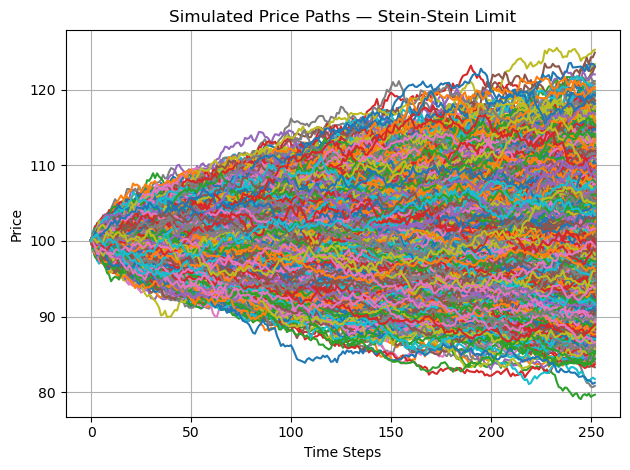

In [16]:
model_ss = pm.ImprovedSteinStein(
    r=0.0953, rho=0.0, kappa=4.0, nu=0.1,
    sigma0=0.2, theta0=0.2, lam=0.0, eta=0.0, seed=123
)
res_ss = model_ss.simulate_prices(S0=100.0, T=1.0/12, n_steps_mc=252, n_paths=10000)
pm.plot(res_ss['S'].T, title="Simulated Price Paths — Stein-Stein Limit")

#### Compare European Option Prices

In [17]:
S, K, tau, vol, theta = 100, 90, 1/12, 0.2, 0.2
price_llh = model_ss.price_call_llh(S, K, tau, vol, theta).item()
price_ss  = 10.77  # from Stein-Stein paper Table 1
price_mc  = aop.price_call_mc(res_ss['S'], K=90, T=1.0/12, r=0.0953)['price']

print(f"LLH (SS-limit)  = {price_llh:.10f}")
print(f"Stein-Stein     = {price_ss:.10f}")
print(f"|Δ|             = {abs(price_llh - price_ss):.3e}")
print(f"Monte Carlo     = {price_mc:.10f}")

LLH (SS-limit)  = 10.7668609302
Stein-Stein     = 10.7700000000
|Δ|             = 3.139e-03
Monte Carlo     = 10.7285029617


<a id="sz-table2"></a>
## 5.3 Reproducing Schöbel & Zhu (1999) Table 2

We reproduce Table 2 from Schöbel & Zhu (1999, *Stochastic Volatility With an
Ornstein–Uhlenbeck Process: An Extension*) to confirm the correctness of our
implementation. Their table reports European call prices across three
correlation regimes ($\rho \in \{-0.5, 0, 0.5\}$) and several values of
$\theta_0$, using **SS-limit** parameters ($\lambda=\eta=0$) for which the
LLH formula is exact. For each configuration we compute the LLH (SS-limit)
call price via the analytical formula and compare with a Monte Carlo estimate
and Black-Scholes. The goal here is to validate the implementation, not to
study the impact of $\theta_0$ on the price.

In [18]:
r_sz, kappa_sz, nu_sz = 0.0953, 4.0, 0.1
sigma0_sz = 0.15
tau_sz    = 0.5
S_sz      = 100.0
K_sz      = [90, 95, 100, 105, 110, 115, 120]
theta_values = [0.0, 0.1, 0.2, 0.3]

rho_cases = {"Table 2 (ρ = 0.5)": 0.5,
             "Table 2 (ρ = 0.0)": 0.0,
             "Table 2 (ρ = −0.5)": -0.5}

In [19]:
bs_prices = {K: aop.price_call_bs(S=S_sz, K=K, tau=tau_sz, r=r_sz, vol=sigma0_sz)
             for K in K_sz}
print('Black-Scholes prices (vol=0.15):',
      {K: round(v, 4) for K, v in bs_prices.items()})

Black-Scholes prices (vol=0.15): {90: 14.5154, 95: 10.374, 100: 6.8672, 105: 4.1751, 110: 2.3216, 115: 1.1804, 120: 0.5502}


In [32]:
for case_name, rho_val in rho_cases.items():
    print(f'\n=== {case_name} ===')
    rows = {'BS': bs_prices}
    for theta0_val in theta_values:
        model_sz = pm.ImprovedSteinStein(
            r=r_sz, rho=rho_val, kappa=kappa_sz, nu=nu_sz,
            sigma0=sigma0_sz, theta0=theta0_val, lam=0.0, eta=0.0, seed=123
        )
        llh_row, mc_row = {}, {}
        for K in K_sz:
            res = pm.european_prices(
                model_sz, S0=S_sz, K=K, tau=tau_sz,
                n_steps_mc=52, n_paths=100_000,
                phi_max=300.0, n_phi=513, n_steps_ode=128
            )
            llh_row[K] = round(res['llh_call'], 4)
            mc_row[K]  = round(res['mc_call'],  4)
        rows[f'LLH θ₀={theta0_val}'] = llh_row
        rows[f'MC  θ₀={theta0_val}'] = mc_row
    df = pd.DataFrame(rows, index=K_sz).T
    df.index.name = f'{case_name} / K'
    display(df)


=== Table 2 (ρ = 0.5) ===


,90,95,100,105,110,115,120
Table 2 (ρ = 0.5) / K,,,,,,,
BS,14.515389,10.373983,6.867182,4.175055,2.321645,1.180438,0.550188
LLH θ₀=0.0,14.189000,9.459500,5.141400,2.173000,0.763200,0.243700,0.074900
MC θ₀=0.0,14.203300,9.479000,5.179400,2.216400,0.788600,0.252400,0.077100
LLH θ₀=0.1,14.262400,9.841900,6.131700,3.466200,1.812100,0.894900,0.425000
MC θ₀=0.1,14.265200,9.848500,6.139100,3.474000,1.819500,0.900600,0.427800
LLH θ₀=0.2,14.722600,10.804000,7.550600,5.043600,3.239500,2.014200,1.220400
MC θ₀=0.2,14.707700,10.784300,7.526600,5.020100,3.218400,1.996900,1.208700
LLH θ₀=0.3,15.607600,12.082000,9.109000,6.703200,4.828000,3.413500,2.376200
MC θ₀=0.3,15.568900,12.034900,9.057700,6.652300,4.779400,3.368100,2.338600



=== Table 2 (ρ = 0.0) ===


,90,95,100,105,110,115,120
Table 2 (ρ = 0.0) / K,,,,,,,
BS,14.515389,10.373983,6.867182,4.175055,2.321645,1.180438,0.550188
LLH θ₀=0.0,14.200500,9.526900,5.268600,2.170200,0.645200,0.150000,0.030400
MC θ₀=0.0,14.212300,9.544700,5.299000,2.211800,0.670800,0.156600,0.031500
LLH θ₀=0.1,14.351200,9.996700,6.254000,3.451000,1.678600,0.731300,0.292200
MC θ₀=0.1,14.350500,9.997000,6.254500,3.456100,1.686400,0.737800,0.294800
LLH θ₀=0.2,14.871100,10.951600,7.632200,5.022000,3.124000,1.844700,1.040200
MC θ₀=0.2,14.850100,10.926000,7.602600,4.994900,3.102000,1.828000,1.030800
LLH θ₀=0.3,15.753700,12.197600,9.161000,6.676400,4.727400,3.258600,2.191800
MC θ₀=0.3,15.708900,12.144300,9.104200,6.621400,4.676500,3.213000,2.155400



=== Table 2 (ρ = −0.5) ===


,90,95,100,105,110,115,120
Table 2 (ρ = −0.5) / K,,,,,,,
BS,14.515389,10.373983,6.867182,4.175055,2.321645,1.180438,0.550188
LLH θ₀=0.0,14.224500,9.600000,5.371900,2.152300,0.504200,0.061100,0.004300
MC θ₀=0.0,14.236000,9.616500,5.396500,2.191400,0.532400,0.067100,0.005200
LLH θ₀=0.1,14.440600,10.129500,6.360800,3.435100,1.529400,0.544700,0.154900
MC θ₀=0.1,14.436200,10.125100,6.356600,3.438100,1.538700,0.553100,0.158000
LLH θ₀=0.2,15.003200,11.083600,7.709900,5.003000,3.004400,1.660200,0.842100
MC θ₀=0.2,14.977600,11.053000,7.675600,4.973100,2.981400,1.644900,0.835400
LLH θ₀=0.3,15.887000,12.306000,9.212900,6.652400,4.626500,3.096900,1.995200
MC θ₀=0.3,15.837500,12.247200,9.151600,6.594200,4.573800,3.051200,1.960600
